<a href="https://colab.research.google.com/github/Unfavl3mon/Predictive-Mainternance-Vibration/blob/main/Predictive-MA-Vibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ==========================================
# Tab 1: Configuration (Setup & Target Point)
# ==========================================

# 1. เลือก Group เครื่องจักร
print("="*65)
print("📌 STEP 1: เลือกประเภทเครื่องจักร (ISO 10816-3)")
print("="*65)
print("1: [Group 2 & 4] - Jockey Pump (15-300kW / ฐานแน่น)")
print("2: [Group 2 & 4] - Jockey Pump (15-300kW / ฐานยืดหยุ่น)")
print("3: [Group 1 & 3] - Cooling Pump / Compressor (>300kW / ฐานแน่น)")
print("4: [Group 1 & 3] - Cooling Pump / Compressor (>300kW / ฐานยืดหยุ่น)")
group_choice = input("กรอกหมายเลข Group (1-4): ")

# 2. เลือกตำแหน่งและทิศทางการวัด (Point & Direction)
print("\n" + "="*65)
print("📌 STEP 2: เลือกตำแหน่งและทิศทางการวัด (Measurement Point)")
print("="*65)
print("A: Motor Outboard Axial (ฝั่งท้าย - แนวแกน)")
print("B: Motor Inboard Axial (ฝั่งหน้า - แนวแกน)")
print("C: Motor Outboard Horizontal (ฝั่งท้าย - แนวนอน)")
pos_choice = input("กรอกตัวเลือกตำแหน่ง (A/B/C): ").upper()

# Mapping ข้อมูล
pos_map = {
    'A': {'name': 'Motor Outboard Axial', 'key': 'Axial'},
    'B': {'name': 'Motor Inboard Axial', 'key': 'Axial'},
    'C': {'name': 'Motor Outboard Horizontal', 'key': 'Horizontal'}
}
sel_pos = pos_map.get(pos_choice, pos_map['A'])

machine_map = {
    '1': 'Jockey', '2': 'Jockey', '3': 'Cooling/Compressor', '4': 'Cooling/Compressor'
}
sel_machine = machine_map.get(group_choice, 'Jockey')

print("\n" + "-"*65)
print(f"✅ เครื่องจักรที่วิเคราะห์  : {sel_machine}")
print(f"✅ ตำแหน่งที่ตรวจพยากรณ์ : {sel_pos['name']}")
print(f"✅ รูปแบบชื่อไฟล์ที่ต้องใช้ : {sel_machine} ... {sel_pos['key']} ...")
print("-" * 65)

📌 STEP 1: เลือกประเภทเครื่องจักร (ISO 10816-3)
1: [Group 2 & 4] - Jockey Pump (15-300kW / ฐานแน่น)
2: [Group 2 & 4] - Jockey Pump (15-300kW / ฐานยืดหยุ่น)
3: [Group 1 & 3] - Cooling Pump / Compressor (>300kW / ฐานแน่น)
4: [Group 1 & 3] - Cooling Pump / Compressor (>300kW / ฐานยืดหยุ่น)
กรอกหมายเลข Group (1-4): 1

📌 STEP 2: เลือกตำแหน่งและทิศทางการวัด (Measurement Point)
A: Motor Outboard Axial (ฝั่งท้าย - แนวแกน)
B: Motor Inboard Axial (ฝั่งหน้า - แนวแกน)
C: Motor Outboard Horizontal (ฝั่งท้าย - แนวนอน)
กรอกตัวเลือกตำแหน่ง (A/B/C): A

-----------------------------------------------------------------
✅ เครื่องจักรที่วิเคราะห์  : Jockey
✅ ตำแหน่งที่ตรวจพยากรณ์ : Motor Outboard Axial
✅ รูปแบบชื่อไฟล์ที่ต้องใช้ : Jockey ... Axial ...
-----------------------------------------------------------------


In [5]:
# ==========================================
# Tab 2: File Upload & Name Validation
# ==========================================
from google.colab import files

print("🚀 กรุณาอัปโหลดไฟล์ .txt ที่ตรงกับเงื่อนไขข้างต้น:")
uploaded = files.upload()

valid_files = []
for filename in uploaded.keys():
    # ตรวจสอบชื่อเครื่องจักร (Jockey หรือ Cooling/CH-06)
    m_check = (sel_machine.lower() in filename.lower()) or ('ch-06' in filename.lower() and 'cooling' in sel_machine.lower())

    # ตรวจสอบทิศทาง (Axial หรือ Horizontal)
    # หมายเหตุ: ในไฟล์คุณ M1A/M1H มักใช้ A=Axial, H=Horizontal
    d_check = (sel_pos['key'].lower() in filename.lower()) or ('m1a' in filename.lower() and sel_pos['key'] == 'Axial') or ('m1h' in filename.lower() and sel_pos['key'] == 'Horizontal')

    if m_check and d_check:
        print(f"✅ ไฟล์ '{filename}' ตรวจสอบผ่าน! (ตรงตามตำแหน่ง {sel_pos['name']})")
        valid_files.append(filename)
    else:
        print(f"❌ [Warning]: ไฟล์ '{filename}' ชื่อไม่ตรงกับเครื่องจักรหรือทิศทางที่เลือก!")
        confirm = input(f"ต้องการใช้ไฟล์ {filename} นี้ต่อหรือไม่? (y/n): ")
        if confirm.lower() == 'y': valid_files.append(filename)

if not valid_files:
    print("‼️ ไม่มีไฟล์ที่พร้อมวิเคราะห์ กรุณาอัปโหลดใหม่")


🚀 กรุณาอัปโหลดไฟล์ .txt ที่ตรงกับเงื่อนไขข้างต้น:


Saving A_CH-06 A_NAA_1490__Jun24.txt to A_CH-06 A_NAA_1490__Jun24.txt
❌ [Warning]: ไฟล์ 'A_CH-06 A_NAA_1490__Jun24.txt' ชื่อไม่ตรงกับเครื่องจักรหรือทิศทางที่เลือก!
ต้องการใช้ไฟล์ A_CH-06 A_NAA_1490__Jun24.txt นี้ต่อหรือไม่? (y/n): y


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

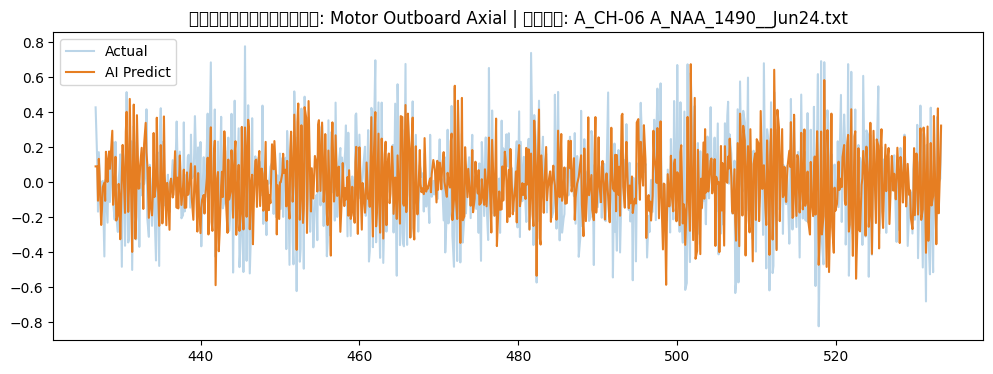

📢 AI วิเคราะห์จุด Motor Outboard Axial:
👉 แนะนำว่าเครื่องจักรอยู่ใน: ZONE C (ผิดปกติ - ควรจำกัดการใช้งานและรีบซ่อม)
👉 ค่าความสั่นที่ทำนายได้: 0.3238 G-s
-----------------------------------------------------------------


In [6]:
# ==========================================
# Tab 3: AI Analysis & Prediction
# ==========================================
import pandas as pd
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# ฟังก์ชันอ่านไฟล์ (เวอร์ชันแก้ไข Error: could not convert string to float)
def parse_data(path):
    d = []
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        lines = f.readlines()
    start = False
    for l in lines:
        if "---------" in l: start = True; continue
        if start:
            p = l.split()
            if not p: continue
            try:
                # แก้ไขปัญหาScientific Notation: เปลี่ยนจาก '9.1-5' เป็น '9.1e-5'
                cleaned_p = []
                for x in p:
                    # ถ้าเจอตัวเลขที่มีเครื่องหมาย - อยู่ตรงกลาง (ไม่ใช่ตัวหน้าสุด) ให้เติม 'e'
                    if '-' in x and not x.startswith('-') and 'e' not in x.lower():
                        x = x.replace('-', 'e-')
                    cleaned_p.append(x)

                nums = [float(x) for x in cleaned_p]
                for i in range(0, len(nums), 2):
                    if i+1 < len(nums): d.append([nums[i], nums[i+1]])
            except ValueError as e:
                # ข้ามบรรทัดที่แปลงไม่ได้จริงๆ (เช่น มีตัวอักษรปน)
                continue

    return pd.DataFrame(d, columns=['Time_ms', 'Amplitude']).sort_values('Time_ms').reset_index(drop=True)

# ฟังก์ชันเช็คโซน ISO
def check_zone(val, g):
    val = abs(val)
    t = {'1': {'D': 0.39, 'C': 0.25, 'B': 0.13},
         '2': {'D': 0.61, 'C': 0.39, 'B': 0.19},
         '3': {'D': 0.61, 'C': 0.39, 'B': 0.19},
         '4': {'D': 0.61, 'C': 0.61, 'B': 0.39}}.get(g, {'D': 0.39, 'C': 0.25, 'B': 0.13})

    if val >= t['D']: return "ZONE D (อันตรายมาก - เครื่องอาจเสียหาย)", "#e74c3c"
    elif val >= t['C']: return "ZONE C (ผิดปกติ - ควรจำกัดการใช้งานและรีบซ่อม)", "#e67e22"
    elif val >= t['B']: return "ZONE B (ยอมรับได้ - ใช้งานได้ปกติ)", "#f1c40f"
    else: return "ZONE A (ดีเยี่ยม - สภาพเครื่องใหม่)", "#27ae60"

for fname in valid_files:
    df = parse_data(fname)
    for i in range(1, 11): df[f'Lag_{i}'] = df['Amplitude'].shift(i)
    df = df.dropna()

    X, y = df.drop(['Time_ms', 'Amplitude'], axis=1), df['Amplitude']
    split = int(len(df) * 0.8)

    model = XGBRegressor(n_estimators=100)
    model.fit(X.iloc[:split], y.iloc[:split])

    pred_val = model.predict(X.iloc[split:])[-1]
    status, color = check_zone(pred_val, group_choice)

    # กราฟแสดงผล
    plt.figure(figsize=(12, 4))
    plt.plot(df['Time_ms'].iloc[split:], y.iloc[split:], alpha=0.3, label='Actual')
    plt.plot(df['Time_ms'].iloc[split:], model.predict(X.iloc[split:]), color=color, label='AI Predict')
    plt.title(f"พยากรณ์จุดวัด: {sel_pos['name']} | ไฟล์: {fname}")
    plt.legend()
    plt.show()

    print(f"📢 AI วิเคราะห์จุด {sel_pos['name']}:")
    print(f"👉 แนะนำว่าเครื่องจักรอยู่ใน: {status}")
    print(f"👉 ค่าความสั่นที่ทำนายได้: {pred_val:.4f} G-s")
    print("-" * 65)